In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/GEE_Project/india_district_growth.csv')

# See what columns you have
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head())

Columns: ['system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE', 'ADM1_NAME', 'ADM2_CODE', 'ADM2_NAME', 'DISP_AREA', 'EXP2_YEAR', 'STATUS', 'STR2_YEAR', 'Shape_Area', 'Shape_Leng', 'builtup_change', 'ndvi_change', 'ntl_change', '.geo']
Shape: (573, 17)
           system:index  ADM0_CODE ADM0_NAME  ADM1_CODE ADM1_NAME  ADM2_CODE  \
0  000100000000000016f6        115     India       1492   Haryana      17660   
1  000100000000000016f7        115     India       1492   Haryana      17661   
2  000100000000000016f8        115     India       1492   Haryana      17662   
3  000100000000000016fb        115     India       1492   Haryana      17665   
4  000100000000000016ff        115     India       1492   Haryana      70134   

      ADM2_NAME DISP_AREA  EXP2_YEAR        STATUS  STR2_YEAR  Shape_Area  \
0        Karnal        NO       3000  Member State       1990    0.240933   
1   Kurukshetra        NO       3000  Member State       1990    0.171739   
2  Mahendragarh        NO       300

In [ ]:
# Drop rows where signal columns are empty
df = df.dropna(subset=['ntl_change', 'ndvi_change', 'builtup_change'])

print(f"Districts after cleaning: {len(df)}")

Districts after cleaning: 573


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize each signal to 0-1
df['ntl_score']     = scaler.fit_transform(df[['ntl_change']])
df['ndvi_score']    = scaler.fit_transform(df[['ndvi_change']])
df['builtup_score'] = scaler.fit_transform(df[['builtup_change']])

# Weighted final score
df['growth_score'] = (
    df['ntl_score']     * 0.50 +
    df['ndvi_score']    * 0.25 +
    df['builtup_score'] * 0.25
)

# Rank all districts
df['rank'] = df['growth_score'].rank(ascending=False).astype(int)

# Get Top 100
top100 = df[df['rank'] <= 100].sort_values('rank').reset_index(drop=True)

print(top100[['ADM2_NAME', 'ADM1_NAME', 'growth_score', 'rank']].head(10))

             ADM2_NAME      ADM1_NAME  growth_score  rank
0          Mumbai city    Maharashtra      0.640134     1
1                Daman  Daman and Diu      0.508517     2
2           Chandigarh     Chandigarh      0.440740     3
3      Mumbai Suburban    Maharashtra      0.385182     4
4      Bangalore Urban      Karnataka      0.381476     5
5  Gautam Buddha Nagar  Uttar Pradesh      0.372800     6
6                Salem     Tamil Nadu      0.365622     7
7              Chennai     Tamil Nadu      0.362653     8
8             Varanasi  Uttar Pradesh      0.332651     9
9             Namakkal     Tamil Nadu      0.325659    10


In [ ]:
top100.to_csv('/content/drive/My Drive/GEE_Project/top100_districts.csv', index=False)
print("✅ Saved!")

✅ Saved!


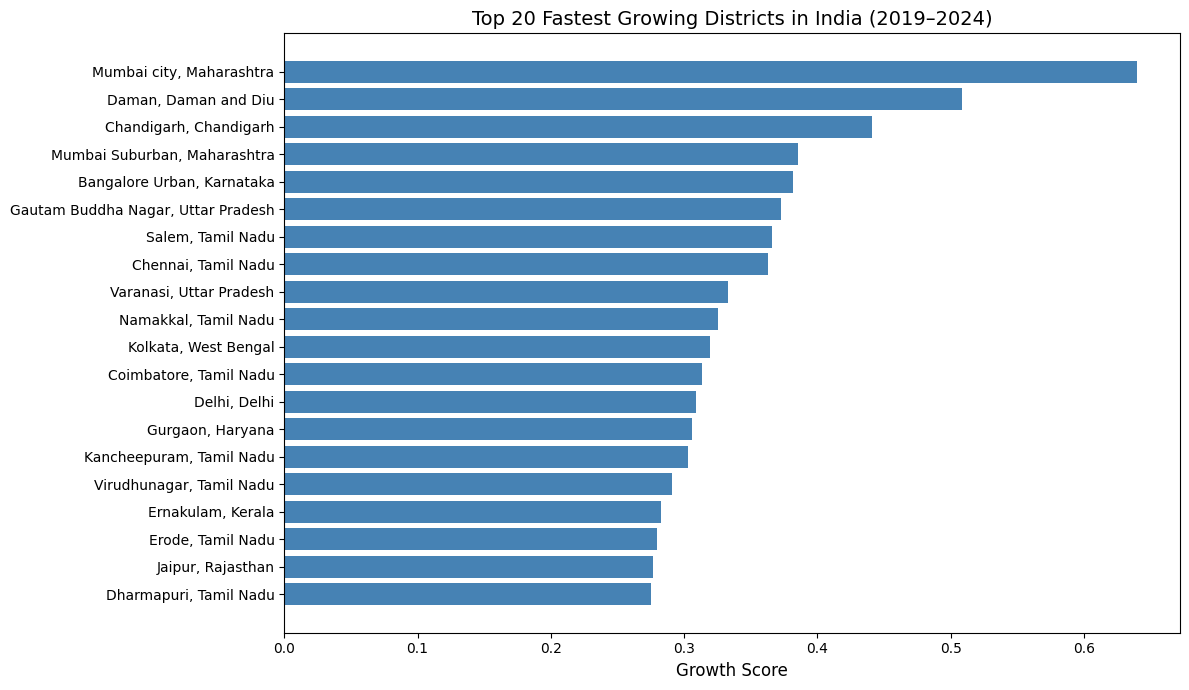

✅ Chart saved!


In [ ]:
import matplotlib.pyplot as plt

top20 = top100.head(20)

plt.figure(figsize=(12, 7))
bars = plt.barh(top20['ADM2_NAME'] + ', ' + top20['ADM1_NAME'],
                top20['growth_score'],
                color='steelblue')
plt.xlabel('Growth Score', fontsize=12)
plt.title('Top 20 Fastest Growing Districts in India (2019–2024)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/My Drive/GEE_Project/top20_chart.png', dpi=150)
plt.show()
print("✅ Chart saved!")


In [ ]:
# Check what columns exist
print(df.columns.tolist())
print(df.head(2))

['system:index', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE', 'ADM1_NAME', 'ADM2_CODE', 'ADM2_NAME', 'DISP_AREA', 'EXP2_YEAR', 'STATUS', 'STR2_YEAR', 'Shape_Area', 'Shape_Leng', 'builtup_change', 'ndvi_change', 'ntl_change', '.geo', 'ntl_score', 'ndvi_score', 'builtup_score', 'growth_score', 'rank']
           system:index  ADM0_CODE ADM0_NAME  ADM1_CODE ADM1_NAME  ADM2_CODE  \
0  000100000000000016f6        115     India       1492   Haryana      17660   
1  000100000000000016f7        115     India       1492   Haryana      17661   

     ADM2_NAME DISP_AREA  EXP2_YEAR        STATUS  ...  Shape_Leng  \
0       Karnal        NO       3000  Member State  ...    2.773671   
1  Kurukshetra        NO       3000  Member State  ...    2.743086   

   builtup_change  ndvi_change  ntl_change  \
0       10.145005  -180.862881    0.987659   
1        7.461106  -183.620891    0.943557   

                                                .geo  ntl_score ndvi_score  \
0  {"type":"Polygon","coordinates":[

In [ ]:
import folium
import json

m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

for _, row in top100.iterrows():
    try:
        # Extract coordinates from .geo column
        geo = json.loads(row['.geo'])
        coords = geo['coordinates']

        # Handle polygon geometry
        if geo['type'] == 'Polygon':
            lons = [c[0] for c in coords[0]]
            lats = [c[1] for c in coords[0]]
            lat = sum(lats) / len(lats)
            lon = sum(lons) / len(lons)
        elif geo['type'] == 'MultiPolygon':
            lons = [c[0] for c in coords[0][0]]
            lats = [c[1] for c in coords[0][0]]
            lat = sum(lats) / len(lats)
            lon = sum(lons) / len(lons)
        else:
            continue

        folium.CircleMarker(
            location=[lat, lon],
            radius=8,
            color='red',
            fill=True,
            fill_color='orange',
            fill_opacity=0.8,
            popup=folium.Popup(
                f"<b>Rank {row['rank']}</b><br>"
                f"{row['ADM2_NAME']}, {row['ADM1_NAME']}<br>"
                f"Score: {row['growth_score']:.3f}",
                max_width=200
            )
        ).add_to(m)
    except Exception as e:
        continue  # skip problematic rows

m.save('/content/drive/My Drive/GEE_Project/top100_map.html')
print("✅ Map saved successfully!")
m  # This displays the map inline in Colab

✅ Map saved successfully!


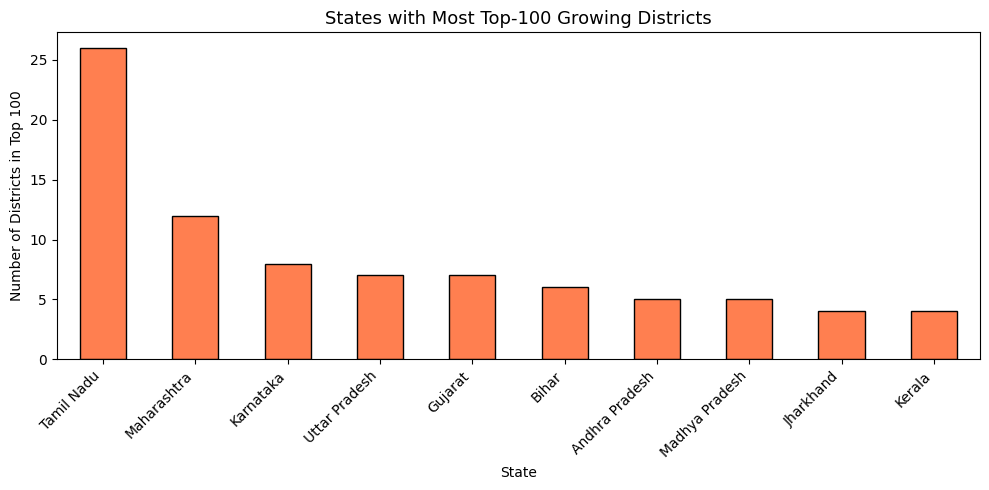

In [ ]:
# Which states have the most top-100 districts?
state_count = top100['ADM1_NAME'].value_counts().head(10)

plt.figure(figsize=(10, 5))
state_count.plot(kind='bar', color='coral', edgecolor='black')
plt.title('States with Most Top-100 Growing Districts', fontsize=13)
plt.xlabel('State')
plt.ylabel('Number of Districts in Top 100')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/GEE_Project/state_summary.png', dpi=150)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load CSV
df = pd.read_csv('/content/drive/My Drive/GEE_Project/india_district_growth.csv')

# Clean
df = df.dropna(subset=['ntl_change', 'ndvi_change', 'builtup_change'])

# Normalize
scaler = MinMaxScaler()
df['ntl_score']     = scaler.fit_transform(df[['ntl_change']])
df['ndvi_score']    = scaler.fit_transform(df[['ndvi_change']])
df['builtup_score'] = scaler.fit_transform(df[['builtup_change']])

# Score
df['growth_score'] = (
    df['ntl_score']     * 0.50 +
    df['ndvi_score']    * 0.25 +
    df['builtup_score'] * 0.25
)

# Rank
df['rank'] = df['growth_score'].rank(ascending=False).astype(int)
top100 = df[df['rank'] <= 100].sort_values('rank').reset_index(drop=True)

# ✅ Print Top 10
print(top100[['rank','ADM2_NAME','ADM1_NAME','growth_score']].head(10).to_string())

Mounted at /content/drive
   rank            ADM2_NAME      ADM1_NAME  growth_score
0     1          Mumbai city    Maharashtra      0.640134
1     2                Daman  Daman and Diu      0.508517
2     3           Chandigarh     Chandigarh      0.440740
3     4      Mumbai Suburban    Maharashtra      0.385182
4     5      Bangalore Urban      Karnataka      0.381476
5     6  Gautam Buddha Nagar  Uttar Pradesh      0.372800
6     7                Salem     Tamil Nadu      0.365622
7     8              Chennai     Tamil Nadu      0.362653
8     9             Varanasi  Uttar Pradesh      0.332651
9    10             Namakkal     Tamil Nadu      0.325659
